In [10]:
# CELL 1: SETUP AND DATA LOADING
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# 1. Dual GPU Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_gpus = torch.cuda.device_count()
print(f"GPUs available: {num_gpus}")
if num_gpus < 2:
    print("WARNING: You don't have 2 GPUs active! Check Kaggle settings.")

# 2. Load Dataset
# Adjust this path if your Kaggle dataset folder is named slightly differently
dataset_path = '/kaggle/input/datasets/waseemalastal/customer-support-ticket-dataset/customer_support_tickets.csv'
df = pd.read_csv(dataset_path)

# Drop missing descriptions and reset index to maintain alignment
df = df.dropna(subset=['Ticket Description', 'Ticket Type']).reset_index(drop=True)

# Keep a subset for rapid testing (Remove [:5000] for the final submission if you want to use all data)
# Using 5000 rows to ensure fast execution and avoid memory timeouts during development
df = df[:5000] 

print(f"Dataset loaded with {len(df)} records.") 

GPUs available: 2
Dataset loaded with 5000 records.


In [11]:
# CELL 2: ONE HOT ENCODING & METADATA
# We must convert 'Ticket Channel' into a binary vector representation.

channels = df['Ticket Channel'].dropna().unique()
channel_to_idx = {ch: i for i, ch in enumerate(channels)}

def encode_channel(channel):
    # Handles unseen categories with a default zero vector
    vec = np.zeros(len(channels))
    if pd.notna(channel) and channel in channel_to_idx:       
        vec[channel_to_idx[channel]] = 1
    return vec

df['Channel_Vector'] = df['Ticket Channel'].apply(encode_channel)
print(f"Found {len(channels)} unique channels. One-hot encoding complete.")  

Found 4 unique channels. One-hot encoding complete.


In [12]:
# CELL 3: SPARSE REPRESENTATION (TF-IDF)

# 1. Custom Tokenizer
def custom_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text) # Basic punctuation removal
    tokens = text.split()
    
    # Generate Bigrams and Trigrams
    bigrams = [" ".join(tokens[i:i+2]) for i in range(len(tokens)-1)]
    trigrams = [" ".join(tokens[i:i+3]) for i in range(len(tokens)-2)]
    return tokens + bigrams + trigrams

# 2. Build Vocabulary (Top 5,000)
print("Building vocabulary...")
all_tokens = []
for desc in df['Ticket Description']:
    all_tokens.extend(custom_tokenizer(desc))

vocab_counts = Counter(all_tokens)
vocab = {word: i for i, (word, _) in enumerate(vocab_counts.most_common(5000))}

# 3. Manual TF-IDF Computation
print("Computing IDF and Sparse Matrices...")
N = len(df)
doc_freqs = Counter()

for desc in df['Ticket Description']:
    unique_tokens = set(custom_tokenizer(desc))
    for t in unique_tokens:
        if t in vocab:
            doc_freqs[t] += 1

# Calculate IDF: log(N / DF)
idf = {t: np.log(N / (1 + count)) for t, count in doc_freqs.items()}

# 4. Create Sparse Tensor
def get_sparse_tfidf(texts):
    indices = []
    values = []
    
    for doc_idx, text in enumerate(texts):
        tokens = custom_tokenizer(text)
        token_counts = Counter([t for t in tokens if t in vocab])
        
        # Calculate vector magnitude for Cosine Normalization
        sq_sum = sum((count * idf[t])**2 for t, count in token_counts.items())
        norm = np.sqrt(sq_sum) if sq_sum > 0 else 1.0
        
        for t, count in token_counts.items():
            indices.append([doc_idx, vocab[t]])
            tf_idf_val = (count * idf[t]) / norm # Normalized
            values.append(tf_idf_val)
            
    i = torch.LongTensor(indices).t()
    v = torch.FloatTensor(values)
    return torch.sparse_coo_tensor(i, v, (len(texts), 5000))

corpus_sparse = get_sparse_tfidf(df['Ticket Description'].tolist()).to(device)
print(f"Corpus Sparse Tensor Shape: {corpus_sparse.shape}")  

Building vocabulary...
Computing IDF and Sparse Matrices...
Corpus Sparse Tensor Shape: torch.Size([5000, 5000])


In [14]:
# CELL 4: DENSE SEMANTIC LAYER

# 1. Load GloVe
glove_path = '/kaggle/input/datasets/anmolkumar/glove-embeddings/glove.6B.300d.txt'
glove_embeddings = {}
embedding_dim = 300
 
print("Loading GloVe vectors...")   
with open(glove_path, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        glove_embeddings[word] = np.asarray(values[1:], dtype='float32')

# 2. OOV Strategy: Random Normal Vector
oov_vector = np.random.normal(scale=0.6, size=(embedding_dim,))

# 3. TF-IDF Weighted Averaging
def get_dense_embeddings(texts):
    embeddings = []
    for text in texts:
        tokens = [t for t in custom_tokenizer(text) if t in vocab]
        if not tokens:
            embeddings.append(np.zeros(embedding_dim))
            continue
            
        vecs = []
        weights = []
        for t in tokens:
            vec = glove_embeddings.get(t, oov_vector) # Apply OOV
            weight = idf.get(t, 1.0)
            vecs.append(vec)
            weights.append(weight)
            
        # Weighted mean
        weighted_avg = np.average(vecs, axis=0, weights=weights)
        
        # Normalize for Cosine Similarity
        norm = np.linalg.norm(weighted_avg)
        if norm > 0:
            weighted_avg = weighted_avg / norm
            
        embeddings.append(weighted_avg)
    return torch.tensor(np.array(embeddings), dtype=torch.float32)

print("Generating Corpus Semantic Embeddings...")
corpus_dense = get_dense_embeddings(df['Ticket Description'].tolist()).to(device)
print(f"Corpus Dense Tensor Shape: {corpus_dense.shape}")

Loading GloVe vectors...
Generating Corpus Semantic Embeddings...
Corpus Dense Tensor Shape: torch.Size([5000, 300])


Replicating Corpus across Dual T4 GPUs...
Running Batch Parallelization Benchmark...
Batch Size 10 processed in 0.8241 seconds.
Batch Size 50 processed in 0.0278 seconds.
Batch Size 100 processed in 0.0067 seconds.


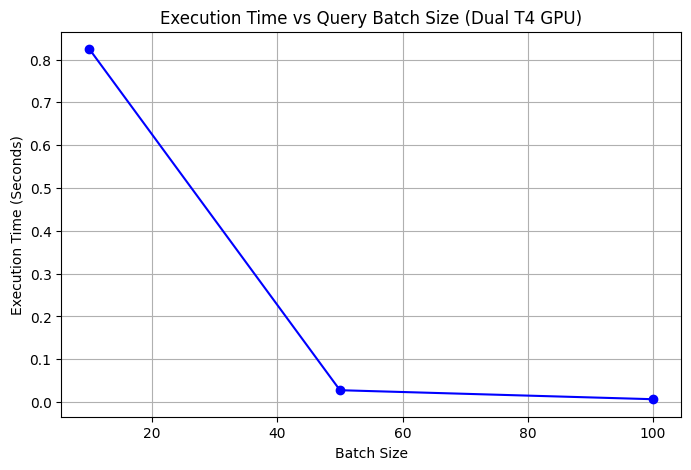

In [16]:
# CELL 5: HYBRID SEARCH AND PARALLELIZATION (FIXED FOR SPARSE TENSORS)

# 1. Manually Replicate Corpus to Both GPUs to avoid DataParallel Scatter Errors
print("Replicating Corpus across Dual T4 GPUs...")
corpus_sparse_0 = corpus_sparse.to('cuda:0')
corpus_dense_0 = corpus_dense.to('cuda:0')

if num_gpus > 1:
    corpus_sparse_1 = corpus_sparse.to('cuda:1')
    corpus_dense_1 = corpus_dense.to('cuda:1')
else:
    corpus_sparse_1 = corpus_sparse_0
    corpus_dense_1 = corpus_dense_0

class HybridRetriever(nn.Module):
    def __init__(self):
        super().__init__()
        
    def forward(self, query_tfidf_dense, query_glove_dense, alpha):
        # 2. Check which GPU this chunk of the batch landed on
        device_idx = query_glove_dense.device.index
        
        # 3. Route to the correct local corpus
        if device_idx == 1:
            c_sparse = corpus_sparse_1
            c_dense = corpus_dense_1
        else:
            c_sparse = corpus_sparse_0
            c_dense = corpus_dense_0

        # Semantic Similarity (Dense matrix multiplication)
        dense_sim = torch.mm(query_glove_dense, c_dense.t())
        
        # Keyword Similarity
        # We multiply the localized Sparse Corpus by the Transposed Dense Query Chunk
        sparse_sim = torch.sparse.mm(c_sparse, query_tfidf_dense.t()).t()
        
        return alpha * sparse_sim + (1 - alpha) * dense_sim

# Deploy to Dual T4 GPUs
model = HybridRetriever()
if num_gpus > 1:
    model = nn.DataParallel(model)
model = model.to(device)

# --- PERFORMANCE OPTIMIZATION PLOT (Task 3) ---
print("Running Batch Parallelization Benchmark...")
batch_sizes = [10, 50, 100]
times = []

for b in batch_sizes:
    # Notice we convert the *query* to dense. This is safe for RAM because the query is small!
    dummy_sparse_query = get_sparse_tfidf(["test query"] * b).to_dense().to(device)
    dummy_dense_query = get_dense_embeddings(["test query"] * b).to(device)
     
    start_time = time.time()
    # We now ONLY pass the queries and alpha. The model handles the corpus internally!
    _ = model(dummy_sparse_query, dummy_dense_query, alpha=0.4)
    torch.cuda.synchronize() # Wait for GPUs to finish
    end_time = time.time()
    
    times.append(end_time - start_time)
    print(f"Batch Size {b} processed in {end_time - start_time:.4f} seconds.")

plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, times, marker='o', linestyle='-', color='b')
plt.title('Execution Time vs Query Batch Size (Dual T4 GPU)')
plt.xlabel('Batch Size')
plt.ylabel('Execution Time (Seconds)')
plt.grid(True)
plt.show()

In [17]:
# CELL 6: EVALUATION (Precision@5 & Qualitative Analysis)

def retrieve_top_k(query_text, alpha=0.4, k=5):
    # Convert query sparse to DENSE here so DataParallel can handle it
    q_tfidf_dense = get_sparse_tfidf([query_text]).to_dense().to(device)
    q_dense = get_dense_embeddings([query_text]).to(device)
    
    # Pass only the queries
    scores = model(q_tfidf_dense, q_dense, alpha)
    top_k_idx = torch.topk(scores[0], k).indices.cpu().numpy()
    
    return df.iloc[top_k_idx]

# Calculate Precision@5 for 20 Random Samples
test_samples = df.sample(20, random_state=42)
correct_matches = 0

for _, row in test_samples.iterrows():
    query = row['Ticket Description']
    true_type = row['Ticket Type']
    
    results = retrieve_top_k(query, alpha=0.4, k=5)
    pred_types = results['Ticket Type'].tolist()
    
    if true_type in pred_types:
        correct_matches += 1

precision_at_5 = correct_matches / len(test_samples)
print(f"--- Quantitative Evaluation ---")
print(f"Precision@5 for Ticket Type Matching: {precision_at_5 * 100}%")

print("\n--- Qualitative Example (Semantic vs Keyword) ---")
test_q = "My financial charges are incorrect and money is missing."
# Keyword search (alpha = 1.0)
kw_res = retrieve_top_k(test_q, alpha=1.0, k=1).iloc[0]
# Semantic search (alpha = 0.0)
sem_res = retrieve_top_k(test_q, alpha=0.0, k=1).iloc[0]

print(f"Query: {test_q}")
print(f"TF-IDF Match: [{kw_res['Ticket Type']}] {kw_res['Ticket Description'][:100]}...")
print(f"GloVe Match:  [{sem_res['Ticket Type']}] {sem_res['Ticket Description'][:100]}...")

--- Quantitative Evaluation ---
Precision@5 for Ticket Type Matching: 95.0%

--- Qualitative Example (Semantic vs Keyword) ---
Query: My financial charges are incorrect and money is missing.
TF-IDF Match: [Cancellation request] I'm having an issue with the {product_purchased}. Please assist. Thanks.

You're missing $1215, $955...
GloVe Match:  [Cancellation request] I'm having an issue with the {product_purchased}. Please assist. 1 3 5 6 7 8 9 10 11 12 13 14 15 16 ...


In [18]:
# CELL 7: GRADIO DEPLOYMENT
!pip install gradio -q
import gradio as gr

def search_interface(query, alpha):
    results = retrieve_top_k(query, alpha=alpha, k=3)
    
    # Format output for display
    output_data = results[['Ticket Type', 'Ticket Priority', 'Ticket Subject']]
    predicted_type = results.iloc[0]['Ticket Type'] if len(results) > 0 else "Unknown"
    
    return predicted_type, output_data

demo = gr.Interface(
    fn=search_interface,
    inputs=[
        gr.Textbox(lines=3, placeholder="Enter ticket description here...", label="Ticket Description"),
        gr.Slider(minimum=0.0, maximum=1.0, value=0.4, step=0.1, label="Alpha (0.0=Semantic GloVe | 1.0=Keyword TF-IDF)")
    ],
    outputs=[
        gr.Textbox(label="Predicted Ticket Type"),
        gr.Dataframe(label="Top 3 Similar Past Resolutions")
    ],
    title="Hybrid Semantic Retrieval System (HSRIS)",
    description="Adjust the Alpha slider to see how results shift between Keyword Overlap and Semantic Meaning."
)

demo.launch(share=True) # Generates the public link for your assignment submission

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://466c181d485b89717e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/queueing.py", line 759, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/route_utils.py", line 354, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 1698, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/anyio/to_thread.py", line 63, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
           ^^^^^